# Propagation of the error and flags

In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "error_propagation"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [3]:
# 200 reports
res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v180526_geo"

cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), ignore_geometry=True)

In [4]:
# The quanti rows are the rows with a value in the impactValue column
df_llm_all_geo_quanti = df_llm_all_geo[df_llm_all_geo['impactValue'].notna()].copy()

## Extraction error

In [50]:
flag_cols = [col for col in df_llm_all_geo.columns if col.startswith("flag_")]

In [ ]:
flags_quanti_value_error = ["flag_value_not_in_text", "flag_percent"]
flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_partial_unit", "flag_unit_nonstd"]
flags_quanti_unit_correction = ["flag_remove_number_unit", "flag_unit_harmonization", "flag_unit_conversion", 
                                "flag_SI_unit_standardization", "flag_non-SI_unit_standardization", 
                                "flag_people_unit_normalization", "flag_currency_conversion"]

flags_subtypes = ["flag_impactSubtype_reclass", "flag_unknown_subtype", "flag_reclass_subtype_from_unit", "flag_impactSubtype_merged", "flag_response_unit"]
flags_hazard = ["flag_hazards_reclass", "flag_hazards_unknown"]
flags_coherence = ["flag_pop_cntry"]
flags_remove_quanti = ["flag_remove_unit", "flag_response_unit"]
flags_remove = ["flag_remove_cat", "flag_remove_hazard"]

In [ ]:
# Correct the flag_value_not_in_text, it should be True/False and not 1/0
def correct_flag_value_not_in_text(row):
    if row['flag_value_not_in_text'] in [1, '1.0', True, 'True']:
        return True
    elif row['flag_value_not_in_text'] in [0, '0.0', False, 'False']:
        return False
    else:
        return row['flag_value_not_in_text']  # Return the original value if it's not recognized

df_llm_all_geo['flag_value_not_in_text'] = df_llm_all_geo.apply(correct_flag_value_not_in_text, axis=1)

flag_SI_unit_standardization_error 1
flag_remove_number_unit_error 0
flag_non-SI_unit_standardization_error 23
flag_unit_conversion_error 0


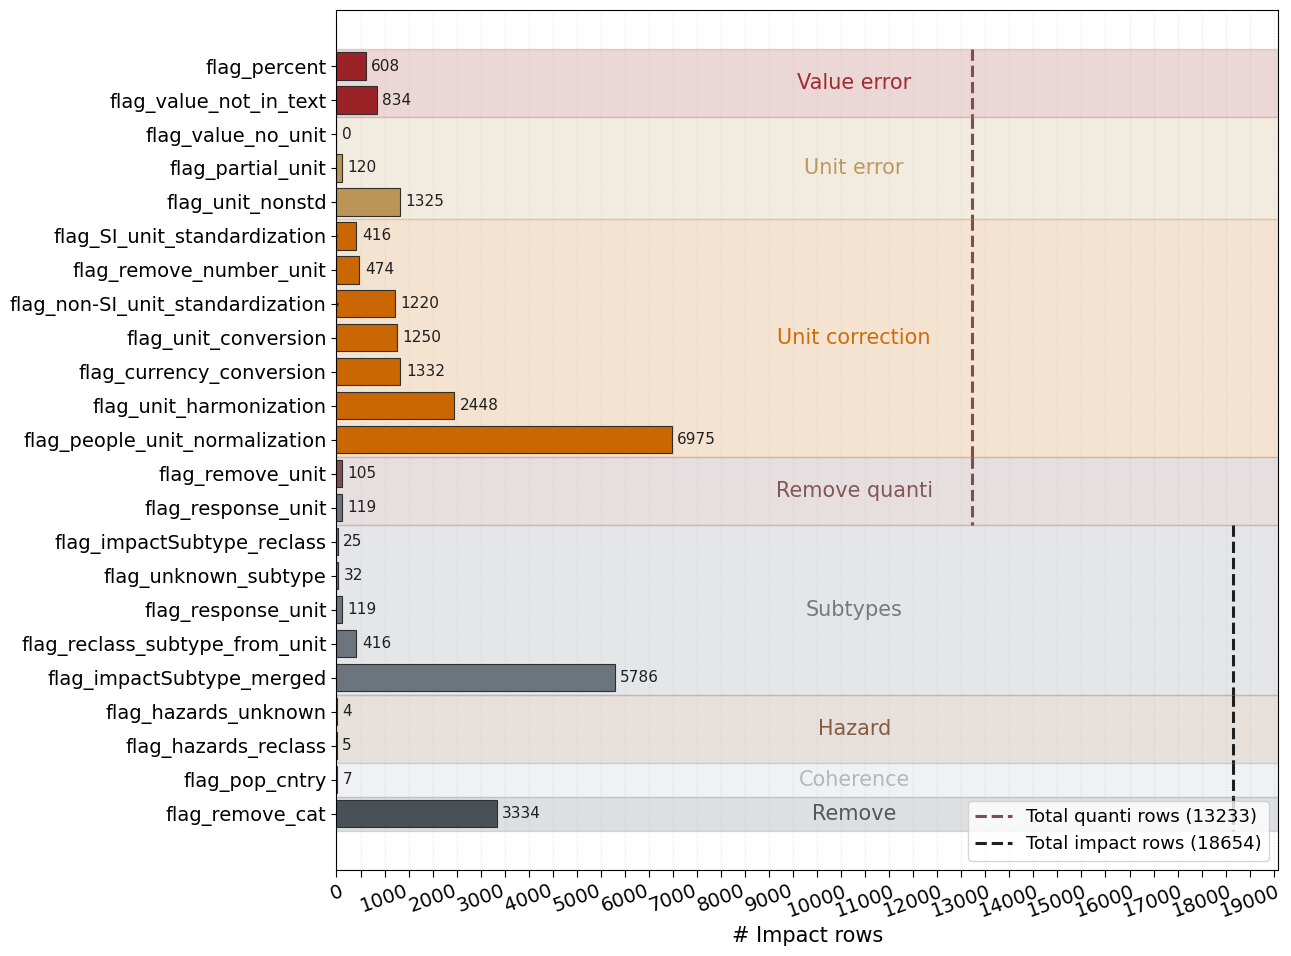

In [ ]:
flags_remove_quanti = ["flag_remove_unit", "flag_response_unit"]
flags_remove = ["flag_remove_cat", "flag_remove_hazard"]

flag_groups = [
    ("Value error", flags_quanti_value_error),
    ("Unit error", flags_quanti_unit),
    ("Unit correction", flags_quanti_unit_correction),
    ("Remove quanti", flags_remove_quanti),
    ("Subtypes", flags_subtypes),
    ("Hazard", flags_hazard),
    ("Coherence", flags_coherence),
    ("Remove", flags_remove),
]
category_palette = {
    "Value error": "#9b2226",
    "Unit error": "#bb9457",
    "Unit correction": "#ca6702",
    "Remove quanti": "#7d4f50",
    "Subtypes": "#6c757d",
    "Hazard": "#7f5539",
    "Coherence": "#adb5bd",
    "Remove": "#495057",
}

quanti_groups = {"Value error", "Unit error", "Unit correction", "Remove quanti"}
other_groups = {"Subtypes", "Hazard", "Coherence", "Remove"}

# Keep the group order used in the notebook and add any remaining flags at the end.
known_flags = {flag for _, group in flag_groups for flag in group}
base_flags = [flag for flag in flag_cols if not flag.endswith("_error")]
remaining_flags = [flag for flag in base_flags if flag not in known_flags]

ordered_flags = []
category_spans = []
flag_to_category = {}
for group_index, (group_name, group_flags) in enumerate(flag_groups):
    existing_flags = [flag for flag in group_flags if flag in base_flags]
    if not existing_flags:
        continue
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    group_counts = (
        source_df[existing_flags]
        .fillna(False)
        .astype(bool)
        .sum()
        .sort_values(ascending=True)
    )
    start = len(ordered_flags)
    ordered_flags.extend(group_counts.index.tolist())
    for flag in group_counts.index.tolist():
        flag_to_category[flag] = group_name
    end = len(ordered_flags) - 1
    category_spans.append((group_name, start, end, group_index))

flag_counts = []
for flag in ordered_flags:
    group_name = flag_to_category.get(flag, "")
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    flag_counts.append(int(source_df[flag].fillna(False).astype(bool).sum()))
flag_counts = pd.Series(flag_counts, index=ordered_flags, dtype=int)

bar_colors = [category_palette.get(flag_to_category.get(flag, ""), "#666666") for flag in ordered_flags]

total_impact_rows = len(df_llm_all_geo)
total_quanti_rows = len(df_llm_all_geo_quanti)
max_x = int(max(total_impact_rows, total_quanti_rows, flag_counts.max())) if len(flag_counts) else max(total_impact_rows, total_quanti_rows)
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)

fig_height = max(5.5, 0.42 * len(ordered_flags))
fig, ax = plt.subplots(figsize=(13, fig_height))
ax.set_axisbelow(True)

for group_name, start, end, _ in category_spans:
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        color=category_palette.get(group_name, "#d9d9d9"),
        alpha=0.18,
        zorder=0,
    )

label_x = x_max * 0.55
for group_name, start, end, _ in category_spans:
    ax.text(
        label_x,
        (start + end) / 2,
        group_name,
        ha="center",
        va="center",
        fontsize=15,
        color=category_palette.get(group_name, "#1f1f1f"),
        alpha=0.95,
        zorder=1.5,
    )

y_positions = np.arange(len(ordered_flags))
ax.barh(y_positions, flag_counts.values, color=bar_colors, edgecolor="#2f2f2f", linewidth=0.8, zorder=2)

for y_pos, flag_name, flag_count in zip(y_positions, ordered_flags, flag_counts.values):
    ax.annotate(
        f"{int(flag_count)}",
        xy=(flag_count, y_pos),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=11,
        color="#1f1f1f",
        zorder=4,
    )
    error_col = f"{flag_name}_error"
    if error_col in df_llm_all_geo.columns:
        source_df = df_llm_all_geo_quanti if flag_to_category.get(flag_name, "") in quanti_groups else df_llm_all_geo
        error_count = int(source_df[error_col].fillna(False).astype(bool).sum())
        print(error_col, error_count)
        if error_count > 0:
            ax.hlines(
                y_pos,
                0,
                min(error_count, flag_count),
                colors="#1f1f1f",
                linestyles="--",
                linewidth=2.2,
                zorder=3,
            )

for group_name, start, end, _ in category_spans:
    if group_name in quanti_groups:
        ax.vlines(
            total_quanti_rows,
            start - 0.5,
            end + 0.5,
            color="#7d4f50",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )
    elif group_name in other_groups:
        ax.vlines(
            total_impact_rows,
            start - 0.5,
            end + 0.5,
            color="#1f1f1f",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )

ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{tick}" if tick % 1000 == 0 else "" for tick in x_ticks])
ax.tick_params(axis="x", which="major", length=5, labelrotation=20, labelsize=14)
ax.set_xlim(0, x_max)
ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_flags, fontsize=14)
ax.set_xlabel("# Impact rows", fontsize=15)
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

ax.legend(handles=[
    Line2D([0], [0], color="#7d4f50", linestyle="--", linewidth=2.2, label=f"Total quanti rows ({total_quanti_rows})"),
    Line2D([0], [0], color="#1f1f1f", linestyle="--", linewidth=2.2, label=f"Total impact rows ({total_impact_rows})"),
], fontsize=13, loc="lower right", frameon=True)

plt.tight_layout()
fig.savefig(path_save_fig / "flags.png", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / "flags.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / "flags.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# Geocoding 

In [10]:
# geocode_unique = pd.read_csv(DATA_OUT_PROC / "geocode_unique_190526.csv")
import ast, json, re
nomin_output = pd.read_csv(DATA_OUT_PROC / "nominatim_output_190526.csv")

# helper parsers to ensure correct dtypes
def parse_match_info(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    s = str(x).strip()
    # try python literal
    try:
        val = ast.literal_eval(s)
        if isinstance(val, dict):
            return val
    except Exception:
        pass
    # try json
    try:
        val = json.loads(s)
        if isinstance(val, dict):
            return val
    except Exception:
        pass
    return {}

def parse_coords(x):
    if pd.isna(x):
        return None
    if isinstance(x, (tuple, list)):
        return tuple(x)
    s = str(x).strip()
    # try python literal
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return tuple(val)
    except Exception:
        pass
    # try json
    try:
        val = json.loads(s)
        if isinstance(val, (list, tuple)):
            return tuple(val)
    except Exception:
        pass
    # fallback: extract numbers
    s_clean = s.strip('()[]')
    parts = re.split(r'[,;\s]+', s_clean)
    try:
        nums = [float(p) for p in parts if p!='']
        if len(nums) >= 2:
            return (nums[0], nums[1])
    except Exception:
        pass
    return None

if 'match_info' in nomin_output.columns:
    nomin_output['match_info'] = nomin_output['match_info'].apply(parse_match_info)
if 'coords' in nomin_output.columns:
    nomin_output['coords'] = nomin_output['coords'].apply(parse_coords)

print('Parsed match_info and coords in nomin_output')

Parsed match_info and coords in nomin_output


In [16]:
nomin_output

,location,country,country_iso3,country_iso2,nom_result,coords,match_info
0,Benin,Benin,BEN,BJ,Benin,"(9.5293472, 2.2584408)","{'sim': 1.0, 'admin_level': 0, 'admin_field': ..."
1,Central African Republic,Central African Republic,CAF,CF,Central African Republic,"(7.0323598, 19.9981227)","{'sim': 1.0, 'admin_level': 0, 'admin_field': ..."
2,Chad,Mauritania,MRT,MR,NaN,None,{}
3,Mauritania,Chad,TCD,TD,NaN,None,{}
4,Togo,Togo,TGO,TG,Togo,"(8.7800265, 1.0199765)","{'sim': 1.0, 'admin_level': 0, 'admin_field': ..."
...,...,...,...,...,...,...,...
9854,Chidodo / Chisengezi,Zimbabwe,ZWE,ZW,NaN,None,{}
9855,across the affected district,Malawi,MWI,MW,NaN,None,{}
9856,Mzimba North,Malawi,MWI,MW,NaN,None,{}
9857,Mzimba South,Malawi,MWI,MW,"South Rukuru, Mzimba, Northern Region, Malawi,...","(-11.1491701, 33.6410906)","{'sim': 0.5, 'admin_level': 3, 'admin_field': ..."


In [23]:
nomin_output['nom_result'][13]

'Blitta, Centrale Region, Togo'

In [24]:
from src.data import *
from src.text_processing_functions import *
from src.post_process_functions import *
from src.data_format import format_output
from src.geocoding_utils import *
from src.geocoding import *
from src.hazard_def import *
from src.sanity_checks import *

res_savename = None
gpd_files = open_admin_gpd(ADMIN_PATH, "GAUL")

In [25]:
max_workers = min(10, (os.cpu_count() or 1) + 2)
df_geo_individual_locs = run_parallel_geocode(
    nomin_output.iloc[:4], gpd_files, print_info=False, max_workers=max_workers
)

Geocoding locations: 100%|██████████| 4/4 [00:00<00:00, 4014.65it/s]


In [27]:
# Convert nominatim output to polygons
start = time.time()
max_workers = min(10, (os.cpu_count() or 1) + 2)
df_geo_individual_locs = run_parallel_geocode(
    nomin_output, gpd_files, print_info=False, max_workers=max_workers
)
end = time.time()
time_open = (end - start) / 60
LOGGER.info("Time to geocode all locations %.2fmins", time_open)
if not res_savename :
    geocode_unique_save_path = DATA_OUT_PROC / (f"geocode_unique_{dt.date.today().strftime('%d%m%y')}.gpkg")
else :  
    geocode_unique_save_path = DATA_OUT_PROC / (f"geocode_unique_{dt.date.today().strftime('%d%m%y')}.gpkg")
atomic_gpkg_save(
    df_geo_individual_locs, geocode_unique_save_path, layer_name="multipolygons"
)
LOGGER.info("Geocoded unique locations saved in %s", geocode_unique_save_path)

[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
Geocoding locations:   0%|          | 0/9859 [00:00<?, ?it/s][try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object has no attribute 'raw'. Falling back to country level.
[try_fallback_strategies] 'str' object has no attribute 'raw'. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object has no attribute 'raw'. Fallin

In [29]:
df_geo_individual_locs.flag_geocoding_country.count()

np.int64(10332)

In [30]:
len(df_geo_individual_locs)

10339

In [33]:
df_geo_individual_locs.iloc[:50]

,iso3_code,gaul0_code,ADMIN_0,geometry,finest_level,locationOsm,locationPolygon,flag_geocoding_osm,flag_geocoding_country,location,map_code,gaul1_code,ADMIN_1,gaul2_code,ADMIN_2,continent,disp_en
0,BEN,105.0,Benin,"POLYGON ((1.62266 6.2168, 1.61094 6.25083, 1.7...",0,Benin,Benin,0,0,Benin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CAF,113.0,Central African Republic,"POLYGON ((24.14736 8.66562, 24.19482 8.65337, ...",0,Central African Republic,Central African Republic,0,0,Central African Republic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MRT,144.0,Mauritania,"MULTIPOLYGON (((-16.43755 19.60928, -16.46597 ...",0,Mauritania,Mauritania,0,1,Chad,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCD,114.0,Chad,"POLYGON ((23.98027 19.49663, 23.98066 19.05059...",0,Chad,Chad,0,1,Mauritania,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TGO,162.0,Togo,"POLYGON ((0.90049 10.99326, 0.8748 10.88574, 0...",0,Togo,Togo,0,0,Togo,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,BEN,105.0,Benin,"POLYGON ((1.62266 6.2168, 1.61094 6.25083, 1.7...",0,Benin,Benin,0,1,BENIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CAF,113.0,Central African Republic,"POLYGON ((24.14736 8.66562, 24.19482 8.65337, ...",0,Central African Republic,Central African Republic,0,1,CENTRAL AFRICAN REPUBLIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,MRT,144.0,Mauritania,"MULTIPOLYGON (((-16.43755 19.60928, -16.46597 ...",0,Mauritania,Mauritania,0,1,CHAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,TCD,114.0,Chad,"POLYGON ((23.98027 19.49663, 23.98066 19.05059...",0,Chad,Chad,0,1,MAURITANIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,TGO,162.0,Togo,"POLYGON ((0.90049 10.99326, 0.8748 10.88574, 0...",0,Togo,Togo,0,1,TOGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN
